# 🤖 Aprendizado de Reforço — do GridWorld ao Super Mario

**Disciplina:** Redes Neurais e Deep Learning  
**Aula:** Aprendizado de Reforço (Reinforcement Learning — RL)  
**Objetivo:** entender como um agente aprende a tomar decisões por tentativa e erro e conectar RL clássico a **Deep Reinforcement Learning**.

> **Ideia central:** em vez de receber a resposta correta para cada exemplo, o agente interage com um ambiente, recebe recompensas e aprende uma política que maximiza o retorno acumulado.

### Roteiro visual da aula

**Intuição → MDP → exploração × explotação → Q-Learning → Deep RL → Super Mario 🎮**

Este notebook foi pensado para execução no **Google Colab** e para acompanhamento em aula. As células de demonstração são pequenas; os treinos mais pesados aparecem como etapas opcionais.

## 🎯 Objetivos de aprendizagem

Ao final da aula, você deverá conseguir:

1. explicar a diferença entre **aprendizado supervisionado** e **aprendizado por reforço**;
2. identificar **estado, ação, recompensa, política e episódio**;
3. entender o trade-off **exploration vs. exploitation**;
4. implementar um agente de **Q-Learning tabular**;
5. visualizar como os valores $Q(s,a)$ mudam durante o treinamento;
6. entender por que uma tabela Q deixa de ser prática quando o espaço de estados cresce;
7. conectar Q-Learning a **Deep Q-Networks (DQN)**;
8. enxergar como a mesma ideia chega a ambientes muito mais complexos, como **Super Mario Bros.**.

## 1. Por que Reinforcement Learning é diferente?

No aprendizado supervisionado, normalmente temos:

**entrada → modelo → resposta conhecida → erro → atualização**

Em RL, temos:

**estado → agente escolhe ação → ambiente muda → recompensa → novo estado**

A diferença mais importante é que o agente não recebe, em cada passo, um "gabarito" dizendo qual ação seria correta.

Ele precisa descobrir isso por meio da interação.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(13, 4.8))
ax.set_xlim(0, 13)
ax.set_ylim(0, 5)
ax.axis("off")

boxes = [
    (0.5, 1.5, 2.2, 2.0, "AGENTE", "observa o estado\nescolhe uma ação"),
    (5.4, 1.5, 2.2, 2.0, "AMBIENTE", "executa a ação\nmuda o estado"),
    (10.0, 1.5, 2.2, 2.0, "RECOMPENSA", "feedback:\n+ / 0 / -")
]

for x, y, w, h, title, subtitle in boxes:
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.03,rounding_size=0.12",
        linewidth=2, edgecolor="black", facecolor="white"
    )
    ax.add_patch(patch)
    ax.text(x+w/2, y+h*0.63, title, ha="center", va="center",
            fontsize=16, fontweight="bold")
    ax.text(x+w/2, y+h*0.30, subtitle, ha="center", va="center",
            fontsize=11)

arrows = [
    ((2.7, 2.5), (5.3, 2.5), "ação"),
    ((7.7, 2.5), (9.9, 2.5), "recompensa"),
    ((9.9, 1.9), (7.7, 1.9), "novo estado"),
    ((5.3, 1.9), (2.7, 1.9), "observação")
]

for (x1, y1), (x2, y2), label in arrows:
    ax.add_patch(FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle="->", mutation_scale=18, linewidth=1.8
    ))
    ax.text((x1+x2)/2, (y1+y2)/2 + 0.2, label,
            ha="center", va="center", fontsize=11)

ax.text(6.5, 4.45, "Ciclo de interação no Reinforcement Learning",
        ha="center", fontsize=19, fontweight="bold")
plt.show()

## 2. A linguagem do RL

Vamos formalizar a interação usando um **Markov Decision Process (MDP)**.

| Conceito | Intuição |
|---|---|
| **State $s$** | onde o agente está / o que ele sabe |
| **Action $a$** | decisão que o agente pode tomar |
| **Reward $r$** | feedback recebido após a ação |
| **Policy $\pi(a\|s)$** | estratégia usada para escolher ações |
| **Episode** | uma sequência do início até o fim |
| **Return $G_t$** | soma descontada das recompensas futuras |
| **Discount $\gamma$** | quanto o futuro importa |

A política é justamente aquilo que queremos aprender.

$$
\pi(a\mid s) = P(A_t=a\mid S_t=s)
$$

E o retorno descontado:

$$
G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \dots
$$

### 💡 Pergunta para a turma

Imagine um robô tentando atravessar um corredor.

- chegar ao objetivo: **+10**
- andar um passo: **0**
- bater na parede: **−2**
- cair em um buraco: **−10**

Qual comportamento você espera que o agente aprenda?

> A ideia de RL é transformar esse tipo de objetivo em um problema de tomada de decisão.

## 3. Primeiro experimento: escolha entre duas máquinas

Antes de falar de redes neurais, vamos entender **exploration vs. exploitation** com um Multi-Armed Bandit.

Imagine duas máquinas:

- Máquina A: recompensa média desconhecida
- Máquina B: recompensa média desconhecida

O agente precisa descobrir qual delas é melhor.

Isso já contém uma das ideias mais importantes do RL:

> **Exploitation:** escolher o que parece melhor agora.  
> **Exploration:** experimentar para descobrir algo potencialmente melhor.

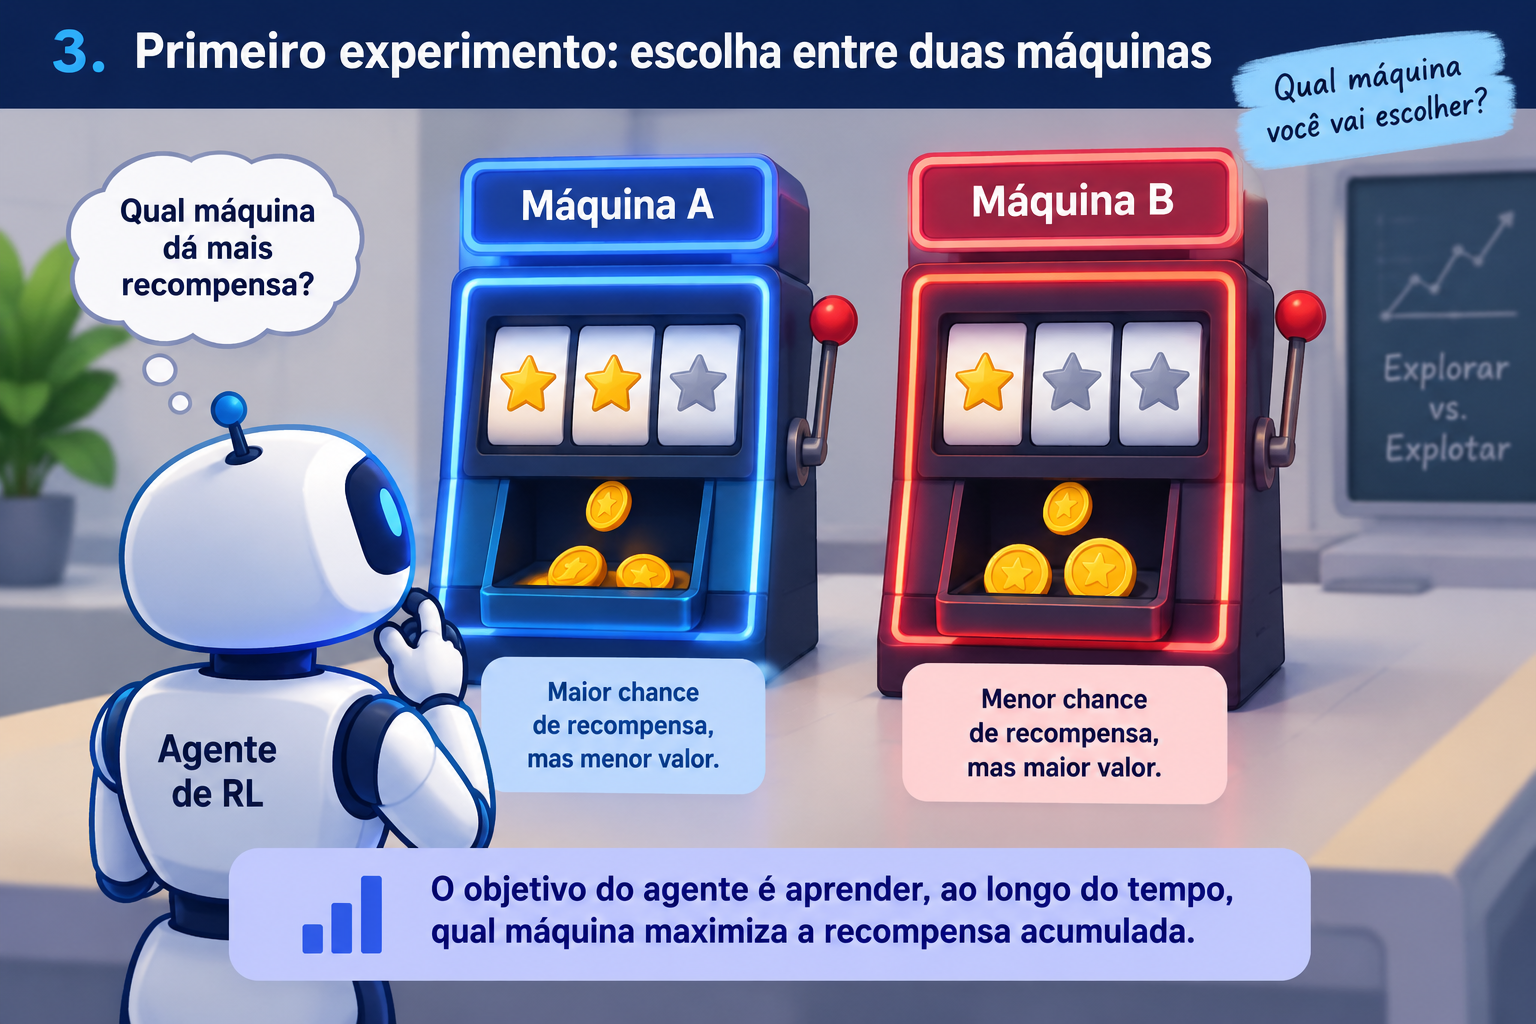

In [ ]:
rng = np.random.default_rng(42)

# Distribuições "verdadeiras" — o agente não conhece esses valores.
n_rounds = 250

def pull_arm(arm):
    if arm == 0:
        # ganha quase sempre
        return 1 if rng.random() < 0.8 else 0

    if arm == 1:
        # ganha raramente, mas paga muito
        return 10 if rng.random() < 0.2 else 0

epsilons = [0.0, 0.10, 0.30, 0.5]
results = {}

for epsilon in epsilons:
    values = np.zeros(2)
    counts = np.zeros(2)
    rewards = []

    for t in range(n_rounds):
        if rng.random() < epsilon:
            action = rng.integers(0, 2)  # exploração
        else:
            action = np.argmax(values)   # explotação

        reward = pull_arm(action)
        counts[action] += 1
        values[action] += (reward - values[action]) / counts[action]
        rewards.append(reward)

    results[epsilon] = {
        "values": values,
        "counts": counts,
        "rewards": np.array(rewards)
    }

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

for epsilon, data in results.items():
    axes[0].plot(
        np.cumsum(data["rewards"]) / np.arange(1, n_rounds + 1),
        label=f"ε = {epsilon:.2f}"
    )

axes[0].set_title("Recompensa média acumulada")
axes[0].set_xlabel("Rodada")
axes[0].set_ylabel("Recompensa média")
axes[0].legend()

width = 0.25
x = np.arange(2)
for i, epsilon in enumerate(epsilons):
    axes[1].bar(x + i*width, results[epsilon]["counts"],
                width=width, label=f"ε = {epsilon:.2f}")

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(["Máquina A", "Máquina B"])
axes[1].set_ylabel("Número de escolhas")
axes[1].set_title("Exploration × exploitation")
axes[1].legend()

plt.tight_layout()
plt.show()

### 🔎 Observe

Com **ε = 0**, o agente praticamente nunca explora depois que toma uma decisão inicial.

Com algum valor de **ε**, ele continua testando alternativas.

Em problemas reais, esse trade-off aparece o tempo todo:

**recomendações, anúncios, robótica, jogos, manutenção preditiva, alocação de recursos, pricing, logística...**

# 4. Primeiro ambiente: um GridWorld

Agora vamos sair do bandit.

Nosso agente vive em uma pequena grade:

- 🟦 posição atual
- 🟩 objetivo
- ⬛ obstáculo

As ações são:

**↑ ↓ ← →**

O objetivo é aprender o caminho que maximiza a recompensa.

In [ ]:
from matplotlib.colors import ListedColormap

GRID = np.array([
    [0, 0, 0, 0, 2],
    [0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 1, 0],
    [3, 0, 0, 0, 0],
])

# 0 = livre | 1 = obstáculo | 2 = objetivo | 3 = início
cmap = ListedColormap(["white", "black", "#7BC96F", "#6FA8DC"])

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(GRID, cmap=cmap, vmin=0, vmax=3)

labels = {
    (0, 4): "🎯",
    (4, 0): "S",
}

for (r, c), text in labels.items():
    ax.text(c, r, text, ha="center", va="center", fontsize=24,
            fontweight="bold")

for r in range(GRID.shape[0]):
    for c in range(GRID.shape[1]):
        if GRID[r, c] == 1:
            ax.text(c, r, "✕", ha="center", va="center",
                    fontsize=20, color="white")

ax.set_xticks(np.arange(-.5, GRID.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-.5, GRID.shape[0], 1), minor=True)
ax.grid(which="minor", color="gray", linewidth=1)
ax.tick_params(which="both", bottom=False, left=False,
               labelbottom=False, labelleft=False)
ax.set_title("GridWorld — nosso primeiro problema de RL", fontsize=16)
plt.show()

## 5. Vamos construir o ambiente

Repare no padrão:

```text
reset()
   ↓
estado
   ↓
agente escolhe ação
   ↓
step(action)
   ↓
novo estado + reward + fim?
```

Essa interface é a mesma ideia usada por ambientes mais sofisticados.

No Gymnasium, as operações fundamentais são `make`, `reset`, `step` e `render`. citeturn239183search10

In [ ]:
from IPython.display import clear_output
class GridWorld:
    ACTIONS = {
        0: (-1, 0),  # cima
        1: (1, 0),   # baixo
        2: (0, -1),  # esquerda
        3: (0, 1),   # direita
    }

    def __init__(self, max_steps=50):
        self.grid = GRID.copy()
        self.start = (4, 0)
        self.goal = (0, 4)
        self.max_steps = max_steps
        self.reset()

    def reset(self):
        self.position = self.start
        self.steps = 0
        return self.position

    def step(self, action):
        self.steps += 1

        dr, dc = self.ACTIONS[action]
        nr = self.position[0] + dr
        nc = self.position[1] + dc

        # Colisão com parede / obstáculo
        if (
            nr < 0 or nr >= self.grid.shape[0]
            or nc < 0 or nc >= self.grid.shape[1]
            or self.grid[nr, nc] == 1
        ):
            reward = -2
            next_position = self.position
        else:
            next_position = (nr, nc)
            reward = -0.1

        terminated = next_position == self.goal
        if terminated:
            reward = 10

        truncated = self.steps >= self.max_steps and not terminated

        self.position = next_position

        return next_position, reward, terminated, truncated

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
from IPython.display import clear_output

ARROWS = {
    0: "↑",
    1: "↓",
    2: "←",
    3: "→"
}

cmap = ListedColormap([
    "white",    # livre
    "black",    # obstáculo
    "#7BC96F",  # objetivo
    "#6FA8DC"   # início
])


def render_grid(
    env,
    action=None,
    reward=None,
    total_reward=None,
    step=None
):

    clear_output(wait=True)

    fig, ax = plt.subplots(figsize=(7, 7))

    ax.imshow(env.grid, cmap=cmap, vmin=0, vmax=3)

    # Obstáculos
    for r in range(env.grid.shape[0]):
        for c in range(env.grid.shape[1]):

            if env.grid[r, c] == 1:
                ax.text(
                    c,
                    r,
                    "✕",
                    fontsize=20,
                    color="white",
                    ha="center",
                    va="center"
                )

    # Objetivo
    gr, gc = env.goal

    ax.text(
        gc,
        gr,
        "🎯",
        fontsize=28,
        ha="center",
        va="center"
    )

    # Agente
    r, c = env.position

    ax.text(
        c,
        r,
        "🤖",
        fontsize=30,
        ha="center",
        va="center"
    )

    # ==================================================
    # TÍTULO
    # ==================================================

    title = f"Estado atual: {env.position}"

    if action is not None:
        title += f" | Ação: {ARROWS[action]}"

    if reward is not None:
        title += f" | Reward: {reward:.1f}"

    if total_reward is not None:
        title += f" | Total: {total_reward:.1f}"

    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold"
    )

    # ==================================================
    # PAINEL DE STATUS
    # ==================================================

    info_text = ""

    if step is not None:
        info_text += f"Passo: {step}\n"

    if reward is not None:
        info_text += f"Reward: {reward:.1f}\n"

    if total_reward is not None:
        info_text += f"Reward acumulado: {total_reward:.1f}"

    ax.text(
        1.02,
        0.95,
        info_text,
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.9
        )
    )

    ax.set_xticks(
        np.arange(-0.5, env.grid.shape[1], 1),
        minor=True
    )

    ax.set_yticks(
        np.arange(-0.5, env.grid.shape[0], 1),
        minor=True
    )

    ax.grid(which="minor", color="gray", linewidth=1)

    ax.tick_params(
        which="both",
        bottom=False,
        left=False,
        labelbottom=False,
        labelleft=False
    )

    plt.show()


In [ ]:
# =====================================================
# DEMONSTRAÇÃO DE TRANSIÇÃO DE ESTADOS
# =====================================================

env = GridWorld()

state = env.reset()

print("Estado inicial:", state)

render_grid(env)

#TODO faça uma lista actions com as ações desejadas
#Possíveis ações:
#  0: "↑",
#  1: "↓",
#  2: "←",
#  3: "→"

actions = ...

In [ ]:
time.sleep(2)

total_reward = 0

for step, action in enumerate(actions, start=1):

    next_state, reward, terminated, truncated = env.step(action)

    total_reward += reward

    render_grid(
        env,
        action=action,
        reward=reward,
        total_reward=total_reward,
        step=step
    )

    print(
        f"Passo {step} | "
        f"Ação={ARROWS[action]} | "
        f"Estado={next_state} | "
        f"Reward={reward:.1f} | "
        f"Reward Total={total_reward:.1f}"
    )

    time.sleep(1.5)

    if terminated:
        print("🎉 Objetivo alcançado!")
        print(f"🏆 Reward acumulado final: {total_reward:.1f}")
        break

    if truncated:
        print("⏰ Limite de passos atingido!")
        print(f"🏆 Reward acumulado final: {total_reward:.1f}")
        break

## 6. Q-Learning

A ideia é armazenar uma estimativa:

$$
Q(s,a)
$$

que responde:

> **"Quão boa é tomar a ação $a$ quando estou no estado $s$?"**

A atualização clássica é:

$$
Q(s,a) \leftarrow
Q(s,a) + \alpha
\left[
r + \gamma \max_{a'}Q(s',a') - Q(s,a)
\right]
$$

Interpretando:

- $\alpha$ = learning rate
- $\gamma$ = importância do futuro
- $r$ = recompensa recebida
- $\max Q(s',a')$ = melhor perspectiva a partir do próximo estado

Esse é um ótimo exemplo para separar duas coisas:

**o ambiente define o problema; o algoritmo define como o agente aprende.**

In [ ]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time


In [ ]:
env = GridWorld()

In [ ]:
# TODO defina alpha=0.15 como a taxa de aprendizado do agente.
# Quanto maior alpha, mais rapidamente o agente atualiza os valores da Q-table.
alpha = 0.15

# TODO defina gamma=0.95 como o fator de desconto das recompensas futuras.
# Valores maiores dão mais importância às recompensas que serão obtidas no futuro.
gamma = 0.95

# TODO comece epsilon em 1.0 para que o agente inicialmente explore as ações.
# Epsilon representa a probabilidade de escolher uma ação aleatória.
epsilon = 1.0

# TODO defina epsilon_min=0.05 como a probabilidade mínima de exploração.
epsilon_min = 0.05

# TODO defina epsilon_decay=0.995 para reduzir gradualmente epsilon
# ao longo dos episódios e fazer o agente explorar menos com o tempo.
epsilon_decay = 0.995


# TODO defina n_episodes=1200 como o número total de episódios de treinamento.
n_episodes = 1200


# TODO crie a Q-table usando defaultdict.
# Para cada estado, armazene um vetor com 4 valores de Q,
# correspondentes às ações: cima, baixo, esquerda e direita.
# Q[state] = [Q(cima), Q(baixo), Q(esquerda), Q(direita)]
# Use np.zeros(4) para inicializar os valores de cada novo estado com zero.
Q = defaultdict(lambda: np.zeros(4))

In [ ]:
# TODO crie a função choose_action() para selecionar uma ação usando
# a estratégia epsilon-greedy, equilibrando exploração e exploração.
def choose_action(state, epsilon):

    # TODO gere um número aleatório entre 0 e 1 usando rng.random().
    # Se esse valor for menor que epsilon, escolha uma ação aleatória
    # entre 0 e 3 para explorar o ambiente.
    if ...:
        return ...

    # TODO caso contrário, escolha a ação com maior valor Q no estado atual
    # usando np.argmax(Q[state]) para explorar o que o agente já aprendeu.
    return ...

In [ ]:
episode_rewards = []
episode_steps = []
epsilon_history = []

# Guardar alguns momentos da Q-table
q_snapshots = {}

snapshot_episodes = [0, 1, 5, 20, 100, 500, 1199]


# ============================================================
# TREINAMENTO
# ============================================================

# TODO percorra os n_episodes episódios de treinamento definidos anteriormente.
for episode in range(n_episodes):

    state = env.reset()

    total_reward = 0

    for step in range(env.max_steps):

        # TODO escolha uma ação usando a estratégia epsilon-greedy
        # implementada anteriormente na função choose_action().
        action = ...

        # TODO execute a ação no ambiente usando env.step(action).
        # A função retorna o próximo estado, a recompensa e duas indicações
        # de término do episódio: terminated e truncated.
        next_state, reward, terminated, truncated = ...

        # TODO inicialize o target com a recompensa recebida na transição.
        target = ...

        # TODO se o episódio ainda não terminou, atualize o target
        # adicionando gamma multiplicado pela maior estimativa Q do próximo estado.
        if ...:
            target += ...

        # TODO armazene o valor atual de Q para o par estado-ação.
        old_q = ...

        # TODO atualize Q(state, action) usando a regra do Q-Learning:
        # Q(s,a) = Q(s,a) + alpha * (target - Q(s,a)).
        Q[state][action] += ...

        # TODO atualize o estado atual para next_state
        # e acumule a recompensa recebida no episódio.
        state = ...
        total_reward += ...

        # TODO encerre o episódio caso o ambiente tenha indicado
        # que ele terminou ou foi truncado.
        if terminated or truncated:
            break

    # TODO reduza gradualmente epsilon após cada episódio,
    # mantendo seu valor acima de epsilon_min.
    epsilon = ...

    episode_rewards.append(total_reward)
    episode_steps.append(env.steps)
    epsilon_history.append(epsilon)

    # --------------------------------------------------------
    # Salva snapshots da Q-table
    # --------------------------------------------------------
    if episode in snapshot_episodes:

        q_snapshots[episode] = {
            state: values.copy()
            for state, values in Q.items()
        }

In [ ]:
# ============================================================
# 5. RESULTADOS DO TREINAMENTO
# ============================================================

print("=" * 60)
print("TREINAMENTO CONCLUÍDO")
print("=" * 60)

print(f"\nNúmero de episódios: {n_episodes}")

print(
    f"Reward médio nos últimos 100 episódios: "
    f"{np.mean(episode_rewards[-100:]):.2f}"
)

print(
    f"Passos médios nos últimos 100 episódios: "
    f"{np.mean(episode_steps[-100:]):.2f}"
)

print(f"Epsilon final: {epsilon:.3f}")

print(f"Estados visitados: {len(Q)}")

In [ ]:
# ============================================================
# 6. EVOLUÇÃO DO REWARD
# ============================================================

window = 50

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

# ------------------------------------------------------------
# Reward
# ------------------------------------------------------------

axes[0].plot(
    episode_rewards,
    alpha=0.20,
    linewidth=1
)

axes[0].plot(
    np.arange(window - 1, n_episodes),
    moving_average,
    linewidth=3,
    label=f"Média móvel ({window})"
)

axes[0].set_title(
    "Evolução do Reward"
)

axes[0].set_xlabel(
    "Episódio"
)

axes[0].set_ylabel(
    "Reward acumulado"
)

axes[0].legend()

axes[0].grid(alpha=0.25)


# ------------------------------------------------------------
# Epsilon
# ------------------------------------------------------------

axes[1].plot(
    epsilon_history,
    linewidth=3
)

axes[1].set_title(
    "Redução da exploração"
)

axes[1].set_xlabel(
    "Episódio"
)

axes[1].set_ylabel(
    "ε (epsilon)"
)

axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 7. MOSTRAR COMO O VALOR Q EVOLUIU
# ============================================================

# Vamos acompanhar o estado inicial
initial_state = env.start

print("\n")
print("=" * 60)
print("EVOLUÇÃO DOS VALORES Q NO ESTADO INICIAL")
print("=" * 60)

print(
    f"\nEstado inicial: {initial_state}\n"
)

for episode in snapshot_episodes:

    snapshot = q_snapshots[episode]

    values = snapshot.get(
        initial_state,
        np.zeros(4)
    )

    print(f"Episódio {episode:4d}:")

    for action in range(4):

        print(
            f"   {ARROWS[action]} "
            f"Q = {values[action]:7.3f}"
        )

    print()

Os valores Q(s,a) representam a qualidade estimada de cada ação no estado inicial (4,0). No início, o agente ainda não sabe qual ação é melhor, então os valores estão próximos de zero.

Com o treinamento, os valores são atualizados conforme o agente experimenta diferentes caminhos. Quanto maior o Q, mais promissora é a ação naquele estado.

Neste exemplo, ao final:

↑ = 6.380 → melhor ação

→ = 5.551 → segunda melhor

← = 4.058

↓ = 4.053

Assim, para o estado (4,0), o agente aprendeu que subir é a ação mais vantajosa, pois leva a um maior retorno esperado.

In [ ]:
# ============================================================
# 8. VISUALIZAÇÃO DOS Q-VALUES NA GRADE
# ============================================================

fig, axes = plt.subplots(
    1,
    4,
    figsize=(18, 5)
)

action_names = [
    "↑ Cima",
    "↓ Baixo",
    "← Esquerda",
    "→ Direita"
]

for action in range(4):

    q_grid = np.full(
        GRID.shape,
        np.nan
    )

    for r in range(GRID.shape[0]):
        for c in range(GRID.shape[1]):

            if GRID[r, c] != 1:

                state = (r, c)

                if state in Q:
                    q_grid[r, c] = Q[state][action]

    image = axes[action].imshow(
        q_grid,
        cmap="viridis"
    )

    axes[action].set_title(
        f"Q(s, ação = {action_names[action]})"
    )

    axes[action].set_xticks([])
    axes[action].set_yticks([])

    plt.colorbar(
        image,
        ax=axes[action],
        fraction=0.046,
        pad=0.04
    )

plt.suptitle(
    "Valores aprendidos para cada ação",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

A imagem mostra quanto o agente aprendeu que cada ação vale em cada estado. Cada painel corresponde a uma ação diferente:

↑ Cima

↓ Baixo

← Esquerda

→ Direita

In [ ]:
# ============================================================
# 9. POLÍTICA APRENDIDA
# ============================================================

policy_grid = np.empty(
    GRID.shape,
    dtype=object
)

for r in range(GRID.shape[0]):

    for c in range(GRID.shape[1]):

        # Obstáculo
        if GRID[r, c] == 1:

            policy_grid[r, c] = "✕"

        # Objetivo
        elif (r, c) == env.goal:

            policy_grid[r, c] = "🎯"

        # Estado aprendido
        else:

            state = (r, c)

            if state in Q:

                best_action = int(
                    np.argmax(Q[state])
                )

                policy_grid[r, c] = ARROWS[best_action]

            else:

                policy_grid[r, c] = "?"


# ============================================================
# 10. VISUALIZAR A POLÍTICA
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 7)
)

ax.imshow(
    GRID,
    cmap=cmap,
    vmin=0,
    vmax=3
)

for r in range(GRID.shape[0]):

    for c in range(GRID.shape[1]):

        ax.text(
            c,
            r,
            policy_grid[r, c],
            fontsize=25,
            ha="center",
            va="center",
            fontweight="bold"
        )

ax.set_xticks(
    np.arange(-0.5, GRID.shape[1], 1),
    minor=True
)

ax.set_yticks(
    np.arange(-0.5, GRID.shape[0], 1),
    minor=True
)

ax.grid(
    which="minor",
    color="gray",
    linewidth=1
)

ax.tick_params(
    which="both",
    bottom=False,
    left=False,
    labelbottom=False,
    labelleft=False
)

ax.set_title(
    "🧠 Política aprendida pelo agente",
    fontsize=18,
    fontweight="bold"
)

plt.show()

In [ ]:
# ============================================================
# 11. EXECUTAR A POLÍTICA APRENDIDA
# ============================================================

print("\n")
print("=" * 60)
print("EXECUTANDO A POLÍTICA APRENDIDA")
print("=" * 60)

state = env.reset()

trajectory = [
    state
]

actions_taken = []
rewards_taken = []

for step in range(env.max_steps):

    # Melhor ação de acordo com a Q-table
    action = int(
        np.argmax(Q[state])
    )

    next_state, reward, terminated, truncated = env.step(
        action
    )

    trajectory.append(
        next_state
    )

    actions_taken.append(
        action
    )

    rewards_taken.append(
        reward
    )

    state = next_state

    if terminated or truncated:
        break


# ============================================================
# 12. MOSTRAR TRAJETÓRIA
# ============================================================

print(
    "\nTrajetória encontrada:"
)

print(
    " → ".join(
        ARROWS[action]
        for action in actions_taken
    )
)

print(
    f"\nNúmero de passos: {len(actions_taken)}"
)

print(
    f"Reward total: {sum(rewards_taken):.2f}"
)

if terminated:
    print("🎉 O agente chegou ao objetivo!")

else:
    print("❌ O agente não chegou ao objetivo.")

In [ ]:
# ============================================================
# 13. ANIMAÇÃO DA POLÍTICA APRENDIDA
# ============================================================

env.reset()

total_reward = 0

render_grid(
    env,
    total_reward=total_reward,
    step=0
)

time.sleep(1.5)

for step, action in enumerate(
    actions_taken,
    start=1
):

    next_state, reward, terminated, truncated = env.step(
        action
    )

    total_reward += reward

    render_grid(
        env,
        action=action,
        reward=reward,
        total_reward=total_reward,
        step=step
    )

    time.sleep(1.0)

    if terminated:

        print(
            "🎉 O agente aprendeu um caminho até o objetivo!"
        )

        break

    if truncated:

        print(
            "⏰ Limite de passos atingido."
        )

        break

## 🧠 Uma conexão importante

Aqui tivemos algo poderoso:

> **o agente não recebeu uma lista de caminhos corretos.**

Ele descobriu uma política por meio de tentativa e erro.

Mas existe um problema...

### E se tivermos milhões de estados?

Uma tabela Q passa a ser inviável.

É aqui que entra o **Deep Reinforcement Learning**:

$$
\boxed{Q(s,a) \approx Q_\theta(s,a)}
$$

Uma rede neural aprende a aproximar a função $Q$.

# 8. Deep RL: de tabela para rede neural

No **DQN (Deep Q-Network)**, a rede recebe o estado e produz um valor para cada ação:

```text
             ┌───────────────┐
estado  ───► │    Neural      │ ───► Q(s, ↑)
             │    Network     │ ───► Q(s, ↓)
             │               │ ───► Q(s, ←)
             └───────────────┘ ───► Q(s, →)
```

A ação escolhida costuma ser:

$$
a_t = \arg\max_a Q_\theta(s_t, a)
$$

com exploração adicional, por exemplo, via **ε-greedy**.

O salto conceitual é:

**Q-table → função parametrizada por uma rede neural**

## 9. Um exemplo clássico: CartPole

vamos usar um ambiente pequeno em que podemos mostrar Deep RL funcionando com muito menos custo computacional.

No CartPole, o agente controla um carrinho e precisa manter um bastão equilibrado.

Vamos usar **Stable-Baselines3**, uma biblioteca que oferece implementações prontas de algoritmos de RL e segue uma interface semelhante ao estilo de `fit`/`predict` conhecido do ecossistema de ML.

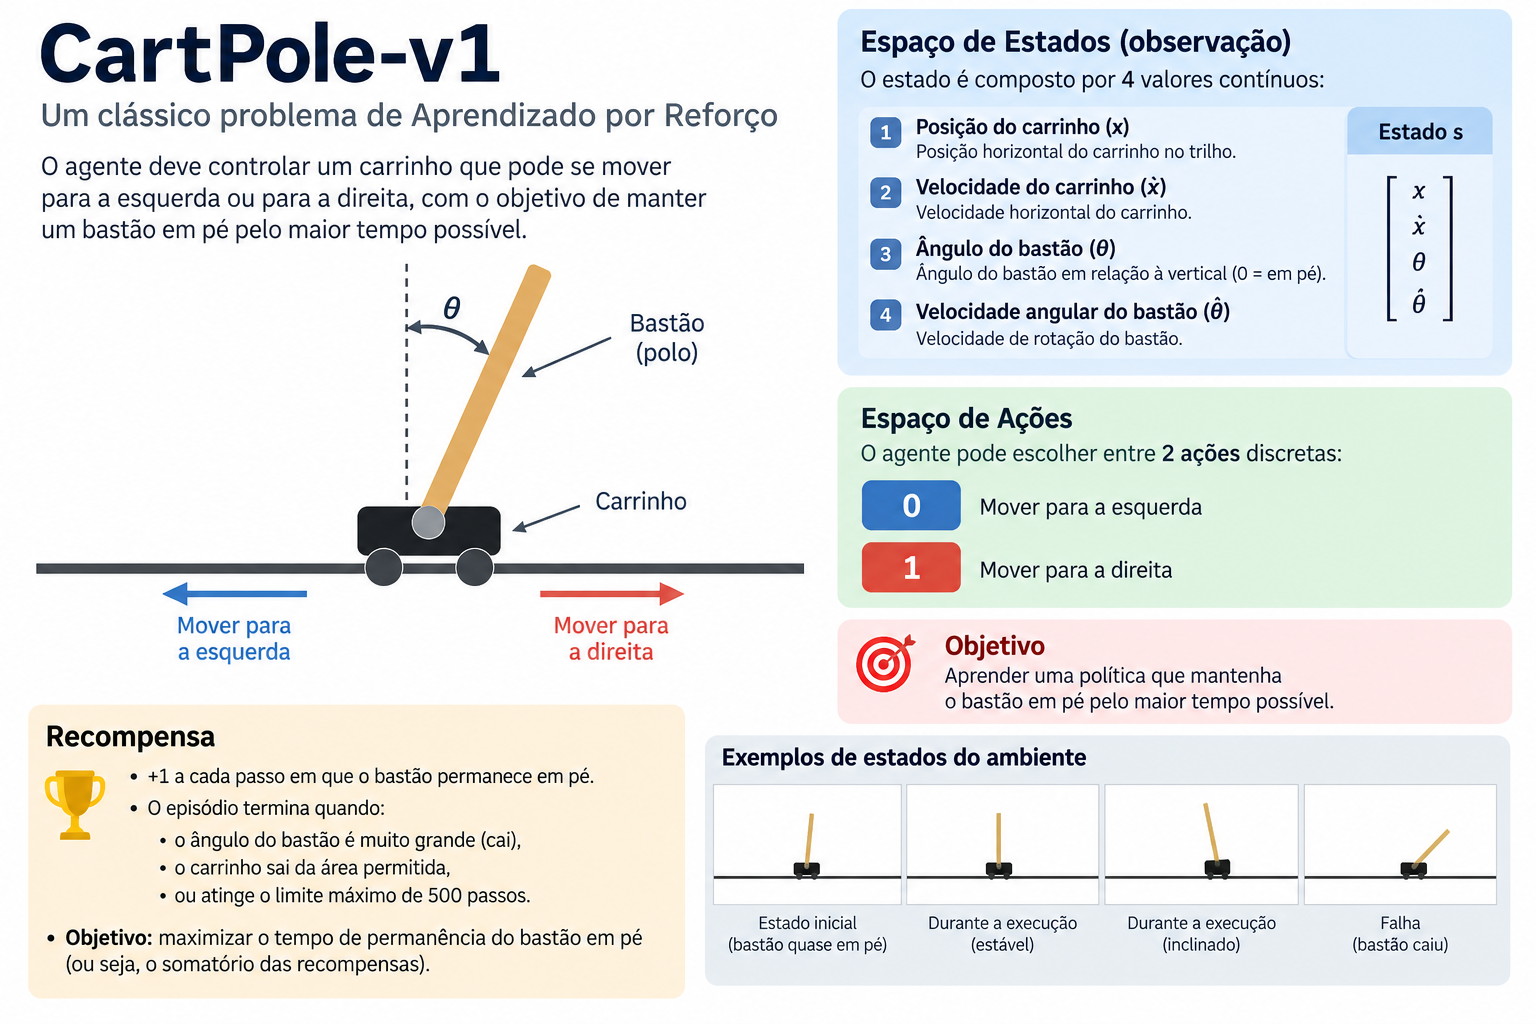

In [ ]:
!pip install -q "gymnasium[classic-control]" "stable-baselines3"

In [ ]:
import gymnasium as gym

In [ ]:
import gymnasium as gym

env = gym.make("CartPole-v1")
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

obs, info = env.reset(seed=42)
print("Primeiro estado:", obs)

### 👀 O que mudou?

No GridWorld, o estado era algo discreto como:

```text
(4, 0)
```

No CartPole, o estado é um vetor contínuo com informações como posição, velocidade e ângulo.

Isso já torna a ideia de uma Q-table muito menos atraente.

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import clear_output
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor


# ============================================================
# 1. CRIANDO O AMBIENTE
# ============================================================

env = gym.make("CartPole-v1", render_mode="rgb_array")
env = Monitor(env)

obs, info = env.reset(seed=42)

print("=" * 60)
print("AMBIENTE: CARTPOLE")
print("=" * 60)

print("\nObservation space:")
print(env.observation_space)

print("\nAction space:")
print(env.action_space)

print("\nEstado inicial:")
print(obs)


# ============================================================
# 2. VISUALIZAR O AMBIENTE ANTES DO TREINAMENTO
# ============================================================

frame = env.render()

fig, ax = plt.subplots(figsize=(10, 4))

ax.imshow(frame)
ax.axis("off")

ax.set_title(
    "CartPole — estado inicial do ambiente",
    fontsize=16,
    fontweight="bold"
)

plt.show()

In [ ]:
# ============================================================
# 3. CALLBACK PARA ACOMPANHAR O TREINAMENTO
# ============================================================

class TrainingCallback(BaseCallback):

    def __init__(self):
        super().__init__()

        self.episode_rewards = []
        self.episode_lengths = []

    def _on_step(self):

        # Verifica se algum episódio terminou
        if self.locals.get("dones") is not None:

            dones = self.locals["dones"]

            for i, done in enumerate(dones):

                if done:

                    infos = self.locals["infos"][i]

                    if "episode" in infos:

                        self.episode_rewards.append(
                            infos["episode"]["r"]
                        )

                        self.episode_lengths.append(
                            infos["episode"]["l"]
                        )

        return True


callback = TrainingCallback()

In [ ]:
# ============================================================
# 4. CRIANDO O DQN
# ============================================================

model = DQN(
    policy=...,
    env=...,
    learning_rate=...,
    buffer_size=...,
    learning_starts=...,
    batch_size=...,
    gamma=...,
    exploration_fraction=...,
    verbose=...,
    seed=...
)

In [ ]:
# ============================================================
# 5. MOSTRAR A REDE NEURAL
# ============================================================

print("\n")
print("=" * 60)
print("ARQUITETURA DO AGENTE")
print("=" * 60)

print(model.policy)

In [ ]:
# ============================================================
# 6. TREINAMENTO
# ============================================================

# TODO treine o agente DQN por 20_000 passos usando total_timesteps=20_000
# e utilize callback para acompanhar ou controlar o treinamento.
model.learn(
    ...
)

In [ ]:
# ============================================================
# 7. VISUALIZAR A EVOLUÇÃO DO APRENDIZADO
# ============================================================

if len(callback.episode_rewards) > 0:

    rewards = np.array(callback.episode_rewards)

    window = 20

    if len(rewards) >= window:

        moving_average = np.convolve(
            rewards,
            np.ones(window) / window,
            mode="valid"
        )

    else:

        moving_average = rewards


    fig, ax = plt.subplots(
        figsize=(11, 5)
    )

    ax.plot(
        rewards,
        alpha=0.25,
        linewidth=1,
        label="Reward por episódio"
    )

    if len(rewards) >= window:

        ax.plot(
            np.arange(window - 1, len(rewards)),
            moving_average,
            linewidth=3,
            label=f"Média móvel ({window})"
        )

    ax.set_title(
        "Aprendizado do agente DQN no CartPole",
        fontsize=16,
        fontweight="bold"
    )

    ax.set_xlabel("Episódio")
    ax.set_ylabel("Reward")

    ax.legend()

    ax.grid(alpha=0.25)

    plt.show()

In [ ]:
# ============================================================
# 8. RESUMO DO APRENDIZADO
# ============================================================

if len(callback.episode_rewards) > 0:

    print("\n")
    print("=" * 60)
    print("RESUMO")
    print("=" * 60)

    print(
        f"Episódios observados: "
        f"{len(callback.episode_rewards)}"
    )

    print(
        f"Reward médio inicial: "
        f"{np.mean(callback.episode_rewards[:20]):.1f}"
    )

    print(
        f"Reward médio final: "
        f"{np.mean(callback.episode_rewards[-20:]):.1f}"
    )

In [ ]:
# ============================================================
# 9. TESTAR O AGENTE APRENDIDO
# ============================================================

test_env = gym.make(
    "CartPole-v1",
    render_mode="rgb_array"
)

obs, info = test_env.reset(seed=123)

frames = []
test_rewards = []

terminated = False
truncated = False

while not (terminated or truncated):

    # O agente escolhe a ação
    action, _ = model.predict(
        obs,
        deterministic=True
    )

    # Executa a ação
    obs, reward, terminated, truncated, info = test_env.step(
        int(action)
    )

    test_rewards.append(reward)

    # Guarda alguns frames
    if len(frames) < 100:

        frames.append(
            test_env.render()
        )

test_env.close()

print("\n")
print("=" * 60)
print("AVALIAÇÃO DO AGENTE")
print("=" * 60)

print(  f"Reward final: "f"{sum(test_rewards):.1f}")

print(  f"Número de passos: " f"{len(test_rewards)}")

In [ ]:
from matplotlib import animation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(10,4))

img = ax.imshow(frames[0])
ax.axis("off")

def animate(i):
    img.set_data(frames[i])
    ax.set_title(f"Agente DQN — passo {i+1}")
    return [img]

anim = animation.FuncAnimation(
    fig,
    animate,
    frames=len(frames),
    interval=100,
    blit=False
)

HTML(anim.to_jshtml())

In [ ]:
def evaluate_agent(model, n_episodes=10):
    eval_env = gym.make("CartPole-v1")
    rewards = []

    for episode in range(n_episodes):
        obs, info = eval_env.reset(seed=100 + episode)
        done = False
        total_reward = 0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = eval_env.step(int(action))
            done = terminated or truncated
            total_reward += reward

        rewards.append(total_reward)

    eval_env.close()
    return np.array(rewards)

eval_rewards = evaluate_agent(model)

print("Rewards:", eval_rewards)
print("Média:", eval_rewards.mean())
print("Desvio padrão:", eval_rewards.std())

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(np.arange(len(eval_rewards)) + 1, eval_rewards)
ax.set_xlabel("Episódio")
ax.set_ylabel("Reward")
ax.set_title("Desempenho do agente DQN no CartPole")
ax.axhline(eval_rewards.mean(), linestyle="--", linewidth=2,
           label=f"Média = {eval_rewards.mean():.1f}")
ax.legend()
plt.show()

# 🎮 10.Bônus: Super Mario Bros.

No Mario, o estado pode ser uma **imagem**.

O agente precisa:

- perceber onde Mario está;
- identificar obstáculos;
- perceber plataformas;
- decidir quando correr;
- decidir quando pular;
- evitar inimigos;
- aprender com recompensas que podem ser atrasadas.

Agora a combinação fica muito interessante:

$$
\boxed{\text{imagem} \rightarrow \text{CNN} \rightarrow \text{política/Q} \rightarrow \text{ação}}
$$

Esse é o ponto em que conceitos das aulas anteriores de **CNN + Deep Learning** encontram **Reinforcement Learning**.

## 11. O ambiente de Super Mario

O projeto `gym-super-mario-bros` fornece ambientes compatíveis com a API moderna do Gymnasium para Super Mario Bros. e outros jogos da franquia. A versão atual documentada pelo projeto é 9.1.0. citeturn239183search0turn239183search12

> ⚠️ **Nota prática:** o ambiente depende de um emulador NES e pode exigir ajustes de ambiente/runtime. A própria documentação do projeto chama atenção para dependências nativas do `nes-py`. citeturn239183search0

Por isso, a parte do Mario foi desenhada em dois níveis:

**Nível A — obrigatório para a aula:** abrir o ambiente, observar o jogo, reduzir o espaço de ações e executar um agente aleatório.

**Nível B — opcional:** conectar o ambiente a um algoritmo de Deep RL e treinar.

In [ ]:
!pip install -q "gym-super-mario-bros==9.1.0"

In [ ]:
import sys
print("Python:", sys.version)

In [ ]:
import gym_super_mario_bros
import gymnasium as gym
import matplotlib.pyplot as plt

from nes_py.wrappers import JoypadSpace
from gym_super_mario_bros.actions import SIMPLE_MOVEMENT


# ============================================================
# 1. CRIANDO O AMBIENTE
# ============================================================

env = gym_super_mario_bros.make("SuperMarioBros-v0")

env = JoypadSpace(
    env,
    SIMPLE_MOVEMENT
)


# ============================================================
# 2. RESETANDO O AMBIENTE
# ============================================================

obs, info = env.reset()


# ============================================================
# 3. INFORMAÇÕES DO AMBIENTE
# ============================================================

print("=" * 65)
print("🎮 SUPER MARIO BROS. — AMBIENTE DE REINFORCEMENT LEARNING")
print("=" * 65)

print("\n🖼️ Espaço de observação:")
print(env.observation_space)

print("\n🎮 Espaço de ações:")
print(env.action_space)

print(f"\n🔢 Número de ações disponíveis: {env.action_space.n}")

In [ ]:
# ============================================================
# 4. VISUALIZANDO A OBSERVAÇÃO
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

ax.imshow(obs)
ax.axis("off")

ax.set_title(
    "O agente recebe uma imagem do jogo como observação",
    fontsize=17,
    fontweight="bold"
)

plt.show()

In [ ]:
# ============================================================
# 5. O QUE O AGENTE ENXERGA?
# ============================================================

print("\n")
print("=" * 65)
print("🧠 O QUE O AGENTE ENXERGA?")
print("=" * 65)

print(
    f"""
A observação é uma imagem com:

Altura      : {obs.shape[0]} pixels
Largura     : {obs.shape[1]} pixels
Canais      : {obs.shape[2]} (RGB)

Shape       : {obs.shape}
"""
)

In [ ]:



# ============================================================
# 6. O QUE O AGENTE PODE FAZER?
# ============================================================

print("=" * 65)
print("🎮 O QUE O AGENTE PODE FAZER?")
print("=" * 65)

for i, action in enumerate(SIMPLE_MOVEMENT):
    print(f"Ação {i}: {action}")

In [ ]:
# ============================================================
# 7. RESUMO VISUAL
# ============================================================

fig, ax = plt.subplots(figsize=(12, 4))

ax.axis("off")

ax.text(
    0.17,
    0.55,
    "🖼️\nOBSERVAÇÃO\n\n"
    f"{obs.shape}",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.8",
        facecolor="lightblue",
        edgecolor="black"
    )
)

ax.text(
    0.50,
    0.55,
    "🧠\nAGENTE\n\n"
    "Deep RL",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.8",
        facecolor="lightyellow",
        edgecolor="black"
    )
)

ax.text(
    0.83,
    0.55,
    "🎮\nAÇÃO\n\n"
    f"{env.action_space.n} opções",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.8",
        facecolor="lightgreen",
        edgecolor="black"
    )
)

ax.annotate(
    "",
    xy=(0.38, 0.55),
    xytext=(0.28, 0.55),
    arrowprops=dict(
        arrowstyle="->",
        linewidth=2
    )
)

ax.annotate(
    "",
    xy=(0.72, 0.55),
    xytext=(0.62, 0.55),
    arrowprops=dict(
        arrowstyle="->",
        linewidth=2
    )
)

ax.set_title(
    "Ciclo básico: observação → agente → ação",
    fontsize=18,
    fontweight="bold"
)

plt.show()

## 12. A observação é uma imagem

Aqui aparece uma conexão direta com a aula de CNN.

O ambiente fornece algo parecido com:

$$
H \times W \times 3
$$

ou seja, uma imagem RGB.

A CNN transforma pixels em representações úteis:

```text
pixels
  ↓
convoluções
  ↓
features visuais
  ↓
representação do estado
  ↓
camada de decisão
  ↓
ação
```

O desafio adicional é que o agente também precisa considerar **tempo e consequências futuras**.

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


# ============================================================
# PIPELINE CNN → RL
# ============================================================

fig, ax = plt.subplots(figsize=(15, 5))

# Limites explícitos
ax.set_xlim(0, 15)
ax.set_ylim(0, 6)
ax.axis("off")


# ============================================================
# ETAPAS
# ============================================================

steps = [
    {
        "x": 1.0,
        "title": "1. OBSERVAÇÃO",
        "subtitle": "Imagem do jogo",
        "detail": "pixels RGB",
        "facecolor": "#DCEEFF"
    },
    {
        "x": 4.7,
        "title": "2. CNN",
        "subtitle": "Extração características",
        "detail": "features visuais",
        "facecolor": "#FFF0CC"
    },
    {
        "x": 8.4,
        "title": "3. DECISÃO",
        "subtitle": "Política / Q-values",
        "detail": "qual ação escolher?",
        "facecolor": "#E4F6E4"
    },
    {
        "x": 12.1,
        "title": "4. AÇÃO",
        "subtitle": "Interação com o jogo",
        "detail": "← → A / B",
        "facecolor": "#FCE2E2"
    }
]


# ============================================================
# DESENHAR AS CAIXAS
# ============================================================

for step in steps:

    x = step["x"]

    box = FancyBboxPatch(
        (x, 1.5),
        2.5,
        2.5,
        boxstyle="round,pad=0.12,rounding_size=0.15",
        linewidth=2,
        edgecolor="black",
        facecolor=step["facecolor"]
    )

    ax.add_patch(box)

    # Título
    ax.text(
        x + 1.25,
        3.45,
        step["title"],
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold"
    )

    # Descrição
    ax.text(
        x + 1.25,
        2.75,
        step["subtitle"],
        ha="center",
        va="center",
        fontsize=12
    )

    # Detalhe
    ax.text(
        x + 1.25,
        2.15,
        step["detail"],
        ha="center",
        va="center",
        fontsize=11,
        style="italic"
    )


# ============================================================
# SETAS ENTRE AS ETAPAS
# ============================================================

for i in range(len(steps) - 1):

    x1 = steps[i]["x"] + 2.5
    x2 = steps[i + 1]["x"]

    arrow = FancyArrowPatch(
        (x1 + 0.1, 2.75),
        (x2 - 0.1, 2.75),
        arrowstyle="->",
        mutation_scale=22,
        linewidth=2.5,
        color="black"
    )

    ax.add_patch(arrow)


# ============================================================
# TÍTULO
# ============================================================

ax.text(
    7.5,
    5.25,
    "Da percepção visual à tomada de decisão",
    ha="center",
    va="center",
    fontsize=20,
    fontweight="bold"
)


# ============================================================
# LOOP DE RETORNO
# ============================================================

ax.annotate(
    "nova observação",
    xy=(1.9, 1.45),
    xytext=(12.8, 1.45),
    arrowprops=dict(
        arrowstyle="->",
        connectionstyle="arc3,rad=-0.25",
        linewidth=2
    ),
    fontsize=11,
    ha="center"
)


plt.show()

# 13. Um primeiro agente para o Mario

Antes de treinar qualquer modelo, vale mostrar um ponto essencial:

> **qualquer política pode interagir com o ambiente.**

Uma política aleatória é ruim, mas serve como baseline.

Esse conceito é extremamente importante em projetos de ML:

**antes de tentar um modelo sofisticado, estabeleça uma referência.**

In [ ]:
# ============================================================
# 1. IMPORTS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from matplotlib.animation import FuncAnimation

from IPython.display import HTML, display

import gymnasium as gym

import gym_super_mario_bros

from nes_py.wrappers import JoypadSpace

from gym_super_mario_bros.actions import SIMPLE_MOVEMENT

from stable_baselines3 import DQN

from gymnasium import spaces


# ============================================================
# 2. WRAPPER — REDUZIR IMAGEM
# ============================================================

class ResizeObservation(gym.ObservationWrapper):

    def __init__(self, env, shape=(84, 84)):

        super().__init__(env)

        self.shape = shape

        self.observation_space = spaces.Box(
            low=0,
            high=255,
            shape=(*shape, 3),
            dtype=np.uint8
        )

    def observation(self, observation):

        image = Image.fromarray(
            np.asarray(observation)
        )

        image = image.resize(
            self.shape,
            Image.Resampling.BILINEAR
        )

        return np.asarray(
            image,
            dtype=np.uint8
        )


# ============================================================
# 3. WRAPPER — FRAME SKIP
# ============================================================

class FrameSkip(gym.Wrapper):

    def __init__(self, env, skip=4):

        super().__init__(env)

        self.skip = skip

    def step(self, action):

        total_reward = 0.0

        terminated = False
        truncated = False

        info = {}

        for _ in range(self.skip):

            obs, reward, terminated, truncated, info = (
                self.env.step(action)
            )

            total_reward += reward

            if terminated or truncated:
                break

        return (
            obs,
            total_reward,
            terminated,
            truncated,
            info
        )


# ============================================================
# 4. CRIAR AMBIENTE DE TREINAMENTO
# ============================================================

env = gym_super_mario_bros.make(
    "SuperMarioBros-v0"
)

# Reduz o espaço de ações para 7 ações
env = JoypadSpace(
    env,
    SIMPLE_MOVEMENT
)

# Repete cada ação por alguns frames
env = FrameSkip(
    env,
    skip=4
)

# Reduz a imagem para 84 × 84
env = ResizeObservation(
    env,
    shape=(84, 84)
)


# ============================================================
# 5. INSPEÇÃO DO AMBIENTE
# ============================================================

obs, info = env.reset(seed=42)

print("=" * 65)
print("🎮 SUPER MARIO BROS. — AMBIENTE")
print("=" * 65)

print("\nObservation space:")
print(env.observation_space)

print("\nAction space:")
print(env.action_space)

print(
    f"\nNúmero de ações: {env.action_space.n}"
)

print(
    f"\nShape da imagem: {obs.shape}"
)


# ============================================================
# 6. MOSTRAR AS AÇÕES
# ============================================================

print("\n")
print("=" * 65)
print("🎮 AÇÕES DISPONÍVEIS")
print("=" * 65)

for i, action in enumerate(SIMPLE_MOVEMENT):

    print(
        f"Ação {i}: {action}"
    )


# ============================================================
# 7. VISUALIZAR A IMAGEM PROCESSADA
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.imshow(obs)

ax.axis("off")

ax.set_title(
    "Imagem recebida pela CNN",
    fontsize=17,
    fontweight="bold"
)

plt.show()


# ============================================================
# 8. CRIAR O AGENTE DQN
# ============================================================

model = DQN(
    policy="CnnPolicy",

    env=env,

    learning_rate=1e-4,

    buffer_size=20_000,

    learning_starts=2_000,

    batch_size=32,

    gamma=0.99,

    train_freq=4,

    gradient_steps=1,

    target_update_interval=2_000,

    exploration_fraction=0.30,

    exploration_initial_eps=1.0,

    exploration_final_eps=0.05,

    verbose=1,

    seed=42,

    device="auto"
)


# ============================================================
# 9. MOSTRAR A ARQUITETURA
# ============================================================

print("\n")
print("=" * 65)
print("🧠 ARQUITETURA DO AGENTE")
print("=" * 65)

print(model.policy)


# ============================================================
# 10. TREINAMENTO
# ============================================================

print("\n")
print("=" * 65)
print("🚀 INICIANDO TREINAMENTO")
print("=" * 65)

print(
    "\nO agente começa explorando o ambiente "
    "e gradualmente passa a utilizar o que aprendeu."
)

model.learn(
    total_timesteps=20_000,
    progress_bar=True
)

print("\n✅ Treinamento concluído!")


# ============================================================
# 11. AMBIENTE PARA AVALIAÇÃO
# ============================================================

eval_env = gym_super_mario_bros.make(
    "SuperMarioBros-v0"
)

eval_env = JoypadSpace(
    eval_env,
    SIMPLE_MOVEMENT
)

eval_env = FrameSkip(
    eval_env,
    skip=4
)

eval_env = ResizeObservation(
    eval_env,
    shape=(84, 84)
)


# ============================================================
# 12. EXECUTAR O AGENTE TREINADO
# ============================================================

obs, info = eval_env.reset(seed=123)

frames = []
actions = []
rewards = []
x_positions = []

max_steps = 100


for step in range(max_steps):

    # --------------------------------------------------------
    # AGENTE ESCOLHE AÇÃO
    # --------------------------------------------------------

    action, _ = model.predict(
        obs,
        deterministic=True
    )

    action = int(action)

    # --------------------------------------------------------
    # AMBIENTE EXECUTA
    # --------------------------------------------------------

    obs, reward, terminated, truncated, info = (
        eval_env.step(action)
    )

    # --------------------------------------------------------
    # ARMAZENAR RESULTADOS
    # --------------------------------------------------------

    frames.append(
        obs.copy()
    )

    actions.append(
        action
    )

    rewards.append(
        reward
    )

    x_positions.append(
        info.get(
            "x_pos",
            np.nan
        )
    )

    # --------------------------------------------------------
    # FINAL DO EPISÓDIO
    # --------------------------------------------------------

    if terminated or truncated:

        break


eval_env.close()


# ============================================================
# 13. RESULTADOS
# ============================================================

cumulative_rewards = np.cumsum(
    rewards
)

print("\n")
print("=" * 65)
print("📊 RESULTADOS")
print("=" * 65)

print(
    f"\nPassos executados: {len(frames)}"
)

print(
    f"Reward total: {sum(rewards):.2f}"
)

print(
    f"Reward médio: {np.mean(rewards):.3f}"
)


valid_x = [
    x
    for x in x_positions
    if not np.isnan(x)
]


if len(valid_x) > 0:

    print(
        f"Posição X inicial: "
        f"{valid_x[0]:.0f}"
    )

    print(
        f"Posição X final: "
        f"{valid_x[-1]:.0f}"
    )

    print(
        f"Progresso: "
        f"{valid_x[-1] - valid_x[0]:.0f}"
    )


# ============================================================
# 14. VISUALIZAÇÃO DO RESULTADO FINAL
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)


# ------------------------------------------------------------
# MARIO
# ------------------------------------------------------------

axes[0].imshow(
    frames[-1]
)

axes[0].axis("off")

axes[0].set_title(
    "Estado final do agente",
    fontsize=16,
    fontweight="bold"
)


# ------------------------------------------------------------
# REWARD
# ------------------------------------------------------------

axes[1].plot(
    cumulative_rewards,
    linewidth=2
)

axes[1].set_title(
    "Reward acumulado",
    fontsize=16,
    fontweight="bold"
)

axes[1].set_xlabel(
    "Passo"
)

axes[1].set_ylabel(
    "Reward acumulado"
)

axes[1].grid(
    alpha=0.25
)


plt.tight_layout()

plt.show()


# ============================================================
# 15. PREPARAR ANIMAÇÃO
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)


# ------------------------------------------------------------
# IMAGEM DO JOGO
# ------------------------------------------------------------

image = axes[0].imshow(
    frames[0]
)

axes[0].axis("off")

axes[0].set_title(
    "Agente DQN",
    fontsize=16,
    fontweight="bold"
)


# ------------------------------------------------------------
# REWARD
# ------------------------------------------------------------

reward_line, = axes[1].plot(
    [],
    [],
    linewidth=2
)

axes[1].set_xlim(
    0,
    len(rewards)
)

reward_min = cumulative_rewards.min()
reward_max = cumulative_rewards.max()


if reward_min == reward_max:

    reward_min -= 1
    reward_max += 1


axes[1].set_ylim(
    reward_min,
    reward_max
)

axes[1].set_xlabel(
    "Passo"
)

axes[1].set_ylabel(
    "Reward acumulado"
)

axes[1].set_title(
    "Aprendizado / retorno",
    fontsize=16,
    fontweight="bold"
)

axes[1].grid(
    alpha=0.25
)


# ============================================================
# 16. TEXTO SOBRE A IMAGEM
# ============================================================

status_text = axes[0].text(
    0.02,
    0.95,
    "",
    transform=axes[0].transAxes,
    fontsize=11,
    color="white",
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="black",
        alpha=0.75
    )
)


# ============================================================
# 17. ANIMAÇÃO
# ============================================================

def update(frame_index):

    step = frame_index

    # Atualiza Mario
    image.set_data(
        frames[step]
    )

    # Atualiza curva
    reward_line.set_data(
        np.arange(step + 1),
        cumulative_rewards[:step + 1]
    )

    # Obtém nomes das ações
    action_name = SIMPLE_MOVEMENT[
        actions[step]
    ]

    # Atualiza informações
    status_text.set_text(
        f"Passo: {step + 1}\n"
        f"Ação: {action_name}\n"
        f"Reward: {rewards[step]:.2f}\n"
        f"Reward acumulado: "
        f"{cumulative_rewards[step]:.2f}"
    )

    axes[0].set_title(
        f"🤖 Agente DQN — passo {step + 1}",
        fontsize=16,
        fontweight="bold"
    )

    return (
        image,
        reward_line,
        status_text
    )


# ============================================================
# 18. GERAR ANIMAÇÃO
# ============================================================

anim = FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=100,
    blit=False
)

plt.close(fig)

display(
    HTML(
        anim.to_jshtml()
    )
)

# 14. Comparando os problemas

| Problema | Estado | Ações | Algoritmo didático |
|---|---|---|---|
| Bandit | sem estado temporal relevante | poucas | ε-greedy |
| GridWorld | discreto | discreto | Q-Learning |
| FrozenLake | discreto + estocástico | discreto | Q-Learning |
| CartPole | vetor contínuo | discreto | DQN |
| Super Mario | imagem + dinâmica temporal | discreto | Deep RL |

Observe a evolução:

**a complexidade do estado aumenta → precisamos de representações mais poderosas.**

# 📚 Referências e leituras

- Gymnasium — documentação geral da API e ambientes de Reinforcement Learning.  
  https://gymnasium.farama.org/

- Gymnasium — tutorial de Q-Learning no FrozenLake.  
  https://gymnasium.farama.org/tutorials/training_agents/frozenlake_q_learning/

- Stable-Baselines3 — documentação e exemplos de algoritmos de RL.  
  https://stable-baselines3.readthedocs.io/

- `gym-super-mario-bros` — ambiente de Super Mario Bros. compatível com Gymnasium.  
  https://github.com/Kautenja/gym-super-mario-bros

- Projeto de referência recente sobre PPO aplicado ao Super Mario Bros.  
  https://github.com/tooichitake/gymnasium-mario